# 1D FDTD Solver: Basic Wave Propagation

This notebook demonstrates the basic operation of the 1D Finite-Difference Time-Domain (FDTD) solver implemented in `src/`. We simulate electromagnetic wave propagation in a heterogeneous medium containing two material slabs with different electromagnetic properties, driven by three Gaussian pulse sources at different times.

The FDTD method discretizes Maxwell's curl equations on a staggered (Yee) grid, leapfrogging the electric field $E_z$ and magnetic field $H_y$ in both space and time. Absorbing boundary conditions (Mur's ABC) are applied at both ends of the domain to simulate an open, infinite space.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.grid import Grid
from src.solver import FDTDSolver1D
from src.sources import SoftSource, gaussian_pulse
from src.boundaries import SimpleABC
from src.materials import add_material_slab
from src.output import animate_field
from functools import partial
import matplotlib as mpl
import numpy as np

mpl.rcParams['animation.embed_limit'] = 50

## Grid and material setup

We simulate a domain of length $L = 20 \,\text{cm}$ with $1 \,\text{mm}$ spatial resolution. Two material slabs are placed in the domain:

- **Slab 1** ($x = 2$–$5 \,\text{cm}$): non-magnetic dielectric with $\mu_{\mathrm{r}} = 4$, which slows the magnetic wave speed by a factor of 2
- **Slab 2** ($x = 13$–$18 \,\text{cm}$): high-permittivity dielectric with $\epsilon_{\mathrm{r}} = 9$, which slows the electric wave speed by a factor of $3$

The Courant number is set to 0.5, giving a stable timestep well within the stability limit $C \leq 1$.

In [2]:
grid = Grid(L=0.2, dx=1e-3, courant=0.5)
add_material_slab(grid, x_start=0.02, x_end=0.05, eps_r=1.0, mu_r=4.0)
add_material_slab(grid, x_start=0.13, x_end=0.18, eps_r=9.0, mu_r=1.0)

print(f"Grid size:     {grid.size} cells")
print(f"Domain length: {grid.L} m")
print(f"dx:            {grid.dx*1e3:.2f} mm")
print(f"dt:            {grid.dt*1e12:.4f} ps")
print(f"Courant number: {grid.courant:.3f}")

Grid size:     200 cells
Domain length: 0.2 m
dx:            1.00 mm
dt:            1.6678 ps
Courant number: 0.500


## Sources

Three Gaussian pulse sources are placed at different positions and times in the domain. A Gaussian pulse is a broadband source, i.e., its frequency content is determined by the pulse width $\sigma$. The pulse takes the form

$$E_{z}(t) = A \exp\bigg({-}\frac{(t-t_0)^2}{2\sigma^2}\bigg).$$

The characteristic frequency bandwidth is approximately $\Delta f \sim 1/\sigma$. All source parameters are given in physical SI units (seconds, metres) so that the simulation results are independent of the grid resolution.

In [3]:
wf1  = partial(gaussian_pulse, t0=5e-10, sigma=1e-10, amplitude=400)
src1 = SoftSource(grid, position=0.1, waveform_func=wf1)

wf2  = partial(gaussian_pulse, t0=15e-10, sigma=0.5e-10, amplitude=200)
src2 = SoftSource(grid, position=0.15, waveform_func=wf2)

wf3  = partial(gaussian_pulse, t0=20e-10, sigma=2e-10, amplitude=400)
src3 = SoftSource(grid, position=0.04, waveform_func=wf3)

## Solver and time loop

Initialize the solver with absorbing boundary conditions and the above sources. The simulation runs for $5 \,\text{ns}$ of physical time. To keep the animation at a manageable size, field snapshots are saved every $5 \,\text{ps}$ rather than every timestep. This gives approximately 1000 frames regardless of the time resolution.

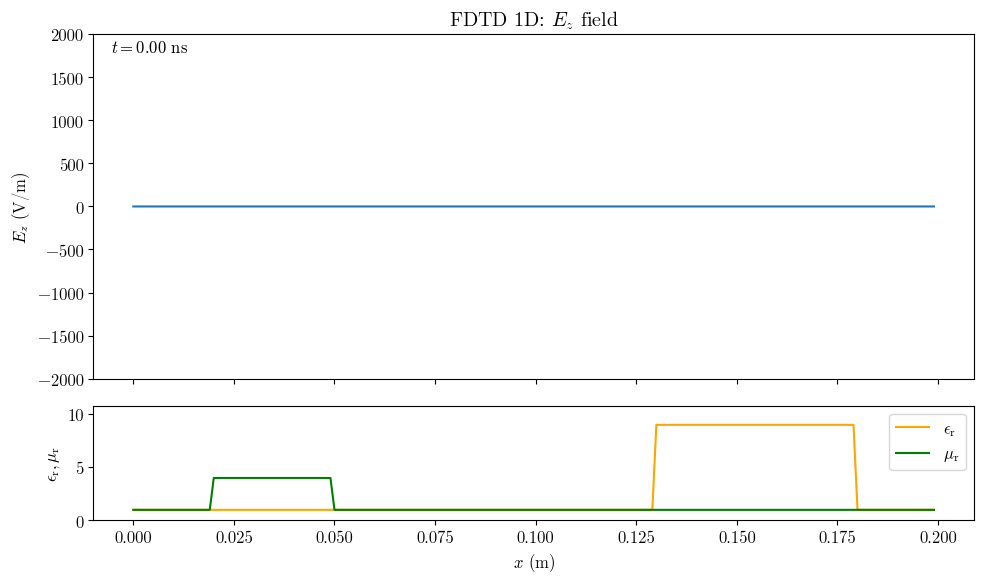

Saving animation to ../assets/01_basic_propagation.mp4...


In [ ]:
abc = SimpleABC()
abc.setup(grid)
solver = FDTDSolver1D(grid, [src1, src2, src3], [abc])

t_end   = 5e-9		# run for a total of 10 nanoseconds
dt_plot = 5e-12		# save a frame every 5 picoseconds
n_steps = round(t_end / grid.dt)

# Run
history_plot = []
next_plot_time = 0.0

for n in range(n_steps):
    solver.step(n)
    t = n * grid.dt
    if (t >= next_plot_time):
        history_plot.append(grid.Ez.copy())
        next_plot_time += dt_plot
        
anim = animate_field(history_plot, grid, ylim=(-2000, 2000), interval=1, dt_plot=dt_plot, filename="../assets/01_basic_propagation.mp4")